In [1]:
from hydra import initialize, compose
import numpy as np
import pyarrow as pa
import duckdb
from PIL import Image, ImageOps
from IPython.display import display, HTML
import pandas as pd
from hydra.core.global_hydra import GlobalHydra

from lensieve.consts import TableName as TN
from lensieve.models.clip_like_embedder import ClipLikeEmbedder
from lensieve.models.model_manager import ModelManager
from lensieve.resources import Resources

try:
    from pillow_heif import register_heif_opener

    register_heif_opener()
except ImportError:
    pass

In [2]:
GlobalHydra.instance().clear()

with initialize(config_path="../configs", version_base=None):
    cfg = compose(config_name="config")

model_name = cfg.models.clip_like.name
batch_size = cfg.models.clip_like.batch_size
embedding_dim = cfg.models.clip_like.embedding_dim

In [3]:
data_root = "../data/large_samsung"
resources = Resources(data_root)
manager = ModelManager()
images_table = resources.lancedb.open_table(TN.IMAGES)

In [4]:
clip_like_embedder = ClipLikeEmbedder(manager, model_name, embedding_dim)
table_name=TN.clip_like_embeddings(clip_like_embedder.model_name)
clip_table = resources.lancedb.open_table(table_name)

images = images_table.to_arrow()

In [5]:
def search_text(text: str, k: int = 20):
    q = clip_like_embedder.run(texts=[text]).numpy().squeeze()

    hits = (
        clip_table
        .search(q, vector_column_name="vector")
        .metric("cosine")
        .limit(k)
        .select(["sha256", "_distance"])
        .to_arrow()
    )

    with resources.connect_duckdb_for_lance() as con:
        return con.execute("""
            SELECT
                i.path,
                h._distance
            FROM hits h
            LEFT JOIN images i
            USING (sha256)
            ORDER BY h._distance
        """).df()

In [48]:
df = search_text("jew")
df

,path,_distance
0,20210429_103256-2.heic,0.861301
1,20210429_103256.heic,0.861301
2,20250314_183428.jpg,0.865763
3,20251219_215746.jpg,0.870353
4,20210728_090847.heic,0.871244
5,20221224_135942.heic,0.872357
6,20241231_210803.jpg,0.872735
7,20241225_200127.jpg,0.872923
8,20251219_215815.jpg,0.875705
9,20190629_222822.jpg,0.877973



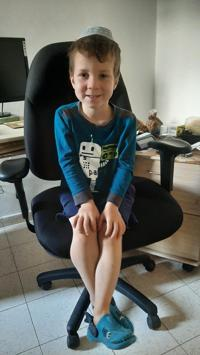
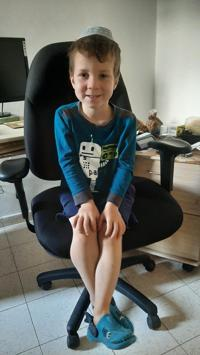
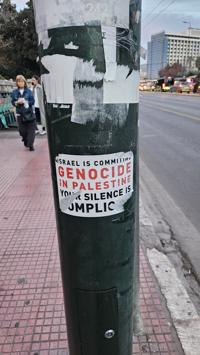
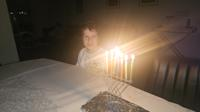
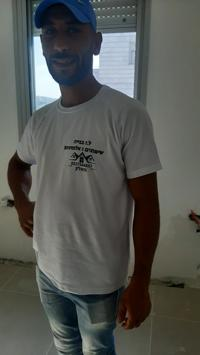
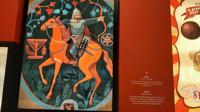
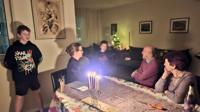
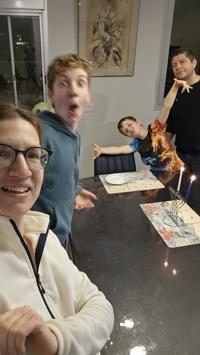
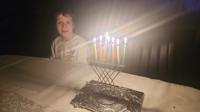
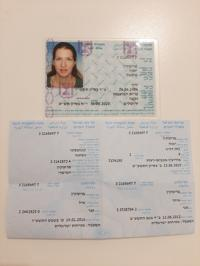
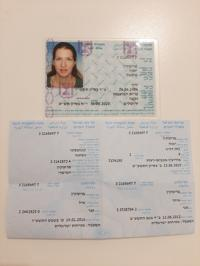
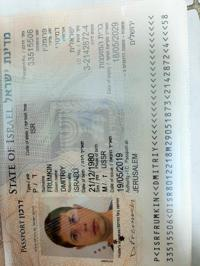
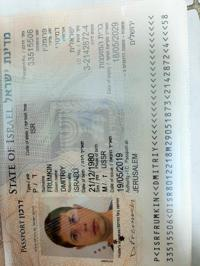
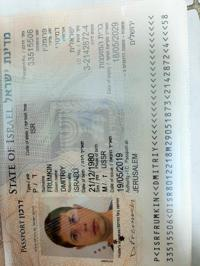
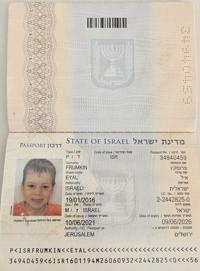
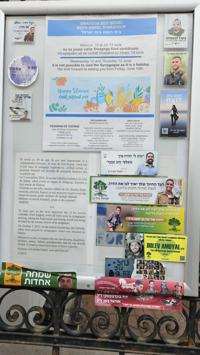
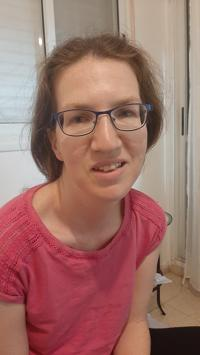
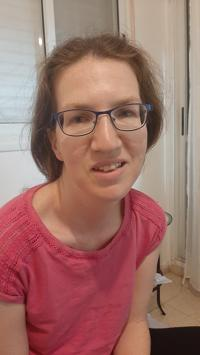
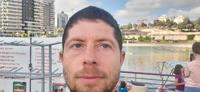
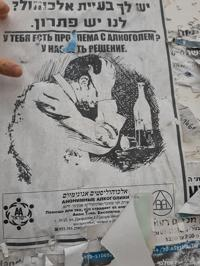
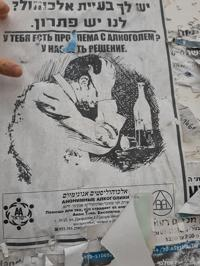
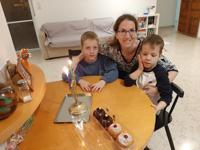
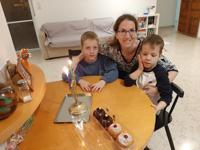
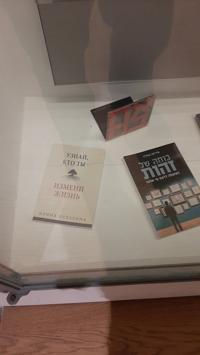
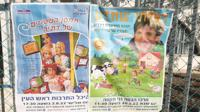
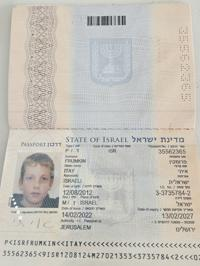
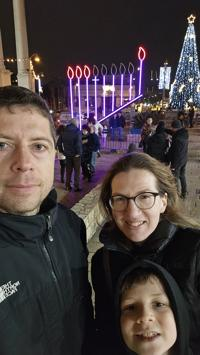

In [49]:
# parameters
MAX_WIDTH = 200   # px
IMAGES_PER_ROW = 5

def render_images(df):
    rows = []
    current_row = []

    for i, row in df.iterrows():
        path = data_root + "/" + row["path"]
        score = row["_distance"]

        try:
            img = Image.open(path)
            img = ImageOps.exif_transpose(img)
            img = img.convert("RGB")

            # resize (keep aspect ratio)
            w, h = img.size
            scale = MAX_WIDTH / w
            img = img.resize((int(w * scale), int(h * scale)))

            # convert to base64 for inline display
            import io, base64
            buffer = io.BytesIO()
            img.save(buffer, format="JPEG")
            img_b64 = base64.b64encode(buffer.getvalue()).decode()

            html = f"""
            <div style="text-align:center; margin:5px;">
                <img src="data:image/jpeg;base64,{img_b64}" />
                <div>{score:.4f}</div>
            </div>
            """
            current_row.append(html)

        except Exception as e:
            current_row.append(f"<div>Error: {e}</div>")

        if len(current_row) == IMAGES_PER_ROW:
            rows.append(current_row)
            current_row = []

    if current_row:
        rows.append(current_row)

    # build table
    table_html = "<table>"
    for row in rows:
        table_html += "<tr>" + "".join(f"<td>{cell}</td>" for cell in row) + "</tr>"
    table_html += "</table>"

    display(HTML(table_html))

render_images(df)

In [29]:

path = data_root + "/20200130_150653-2.heic"
# path = data_root + ""/20251202_135117.jpg"

with Image.open(path) as img:
    image = img.convert("RGB")
                
im_embedding = clip_like_embedder.run(images=[image])[0]
text_embedding = clip_like_embedder.run(texts=["a portrait of a man"])[0]
(im_embedding * text_embedding).sum()

tensor(0.1079, dtype=torch.float16)

In [24]:
import torch
from transformers import AutoModel, AutoProcessor

model_name = "google/siglip2-base-patch16-384"

processor = AutoProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

data_root = "../data/small_samsung"
path = data_root + "/20200130_150653-2.heic"

with Image.open(path) as img:
    image = img.convert("RGB")

images = [image]
#text = ["a portrait of a man"]
#text = ["A picture of a white man's unshaven face"]
text = ["a portrait of a beautiful woman"]

image_inputs = processor(
    images=images,
    return_tensors="pt",
)

text_inputs = processor(
    text=text,
    return_tensors="pt",
    padding="max_length",   # especially important for SigLIP/SigLIP2
    truncation=True,
)

with torch.inference_mode():
    image_features = model.get_image_features(**image_inputs).pooler_output
    text_features = model.get_text_features(**text_inputs).pooler_output

    image_features = torch.nn.functional.normalize(image_features, dim=-1)
    text_features = torch.nn.functional.normalize(text_features, dim=-1)

    similarity = (image_features * text_features).sum(dim=-1)
    
    print(f"Similarity: {similarity}")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Similarity: tensor([0.0411])
